# Задание Pro

Используя модуль **datasets** библиотеки **sklearn**, загрузите базу вин (`.load_wine()`).

Используя шаблон ноутбука, выполните загрузку, подготовку и предобработку данных. Обязательное условие: разделение данных на три выборки осуществляется по шаблону (изменять параметры подготовки данных запрещается)!

Проведите серию экспериментов и добейтесь максимальной точности классификации на тестовой выборке выше 94%.

---

С помощью метода `.summary()` зафиксируйте количество параметров созданной вами нейронной сети.


In [1]:

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Activation, BatchNormalization, Input

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import tensorflow as tf

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.datasets import load_wine

from sklearn.preprocessing import StandardScaler

%matplotlib inline


In [2]:
class Wine_classific:
    def __init__(self, epochs=80, batch_size=16, use_bn=True, learning_rate=0.001, random_state=42):
        self.epochs = epochs
        self.batch_size = batch_size
        self.use_bn = use_bn
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.model = None

    def load_data(self):
        # База
        wine = load_wine()
        x_data = wine.data.astype('float32')
        y_data = wine.target.astype('int64')

        # Фиксация случайности
        np.random.seed(self.random_state)
        tf.keras.utils.set_random_seed(self.random_state)

        # Разбиение: 60% обучение, 20% проверка, 20% тест
        # Параметры разбиения
        x_train_val, x_test, y_train_val, y_test = train_test_split(
            x_data,
            y_data,
            test_size=0.2,
            random_state=self.random_state,
            stratify=y_data
        )

        x_train, x_val, y_train, y_val = train_test_split(
            x_train_val,
            y_train_val,
            test_size=0.25,
            random_state=self.random_state,
            stratify=y_train_val
        )

        # Масштабирование только по обучающей выборке
        x_train = self.scaler.fit_transform(x_train)
        x_val = self.scaler.transform(x_val)
        x_test = self.scaler.transform(x_test)

        return x_train, y_train, x_val, y_val, x_test, y_test

    def create_model(self):
        model = Sequential()
        model.add(Input(shape=(13,)))

        if self.use_bn:
            model.add(Dense(64))
            model.add(BatchNormalization())
            model.add(Activation('relu'))

            model.add(Dense(32))
            model.add(BatchNormalization())
            model.add(Activation('relu'))
        else:
            model.add(Dense(64, activation='relu'))
            model.add(Dense(32, activation='relu'))

        model.add(Dense(16, activation='relu'))

        # 3 класса вина
        model.add(Dense(3, activation='softmax'))

        model.compile(
            optimizer=Adam(learning_rate=self.learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        self.model = model
        return model

    def train_model(self):
        x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()
        model = self.create_model()

        early_stop = EarlyStopping(
            monitor='val_accuracy',
            mode='max',
            patience=10,
            restore_best_weights=True
        )

        history = model.fit(
            x_train,
            y_train,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_data=(x_val, y_val),
            callbacks=[early_stop],
            shuffle=True,
            verbose=1
        )

        train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
        val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=0)
        test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

        self.last_scores = {
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'val_loss': val_loss,
            'val_accuracy': val_accuracy,
            'test_loss': test_loss,
            'test_accuracy': test_accuracy
        }

        return history, test_loss, test_accuracy

    def plot_history(self, history):
        plt.figure(figsize=(14, 5))

        # График ошибки
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Ошибка на обучении')
        plt.plot(history.history['val_loss'], label='Ошибка на проверке')
        plt.title('График ошибки')
        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.legend()
        plt.grid(True)

        # График точности
        plt.subplot(1, 2, 2)
        plt.plot(history.history['accuracy'], label='Точность на обучении')
        plt.plot(history.history['val_accuracy'], label='Точность на проверке')
        plt.title('График точности')
        plt.xlabel('Эпоха')
        plt.ylabel('Точность')
        plt.legend()
        plt.grid(True)

        plt.show()

    def summary(self):
        if self.model is None:
            self.create_model()
        return self.model.summary()


Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.6038 - loss: 0.9013 - val_accuracy: 0.5833 - val_loss: 0.9877
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7830 - loss: 0.6455 - val_accuracy: 0.7222 - val_loss: 0.8794
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8868 - loss: 0.5008 - val_accuracy: 0.7778 - val_loss: 0.7828
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9057 - loss: 0.4055 - val_accuracy: 0.8889 - val_loss: 0.7042
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9245 - loss: 0.3342 - val_accuracy: 0.8889 - val_loss: 0.6303
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9340 - loss: 0.2776 - val_accuracy: 0.9167 - val_loss: 0.5621
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9717 - loss: 0.2340 - val_accuracy: 0.9167 - val_loss: 0.4990
Epoch 8/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9811 - loss: 0.2003 - val_accuracy: 0.9167 - val_loss: 0.4443

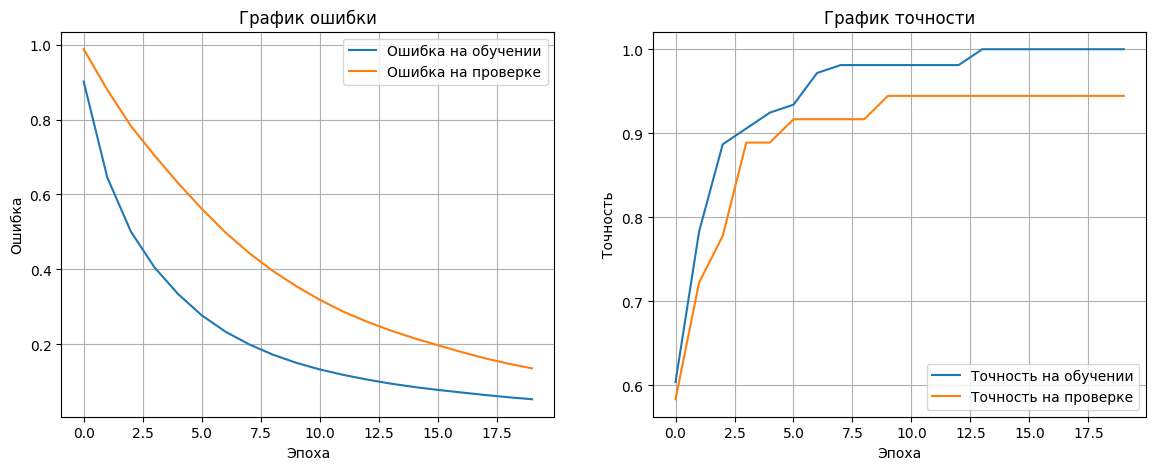

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,435 (44.67 KB)

 Trainable params: 3,747 (14.64 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 7,496 (29.29 KB)

In [3]:
# Обучение основной модели
m1 = Wine_classific(epochs=80, batch_size=16, use_bn=True)
history, loss, accuracy = m1.train_model()

print(f'Ошибка на тестовой выборке: {loss:.4f}')
print(f'Точность на тестовой выборке: {accuracy:.4f}')

m1.plot_history(history)
m1.summary()


In [4]:
# таблица с результатами последнего запуска
results = [[
    m1.epochs,
    m1.batch_size,
    m1.use_bn,
    m1.last_scores['train_accuracy'],
    m1.last_scores['val_accuracy'],
    m1.last_scores['test_accuracy'],
    m1.last_scores['test_loss']
]]

df = pd.DataFrame(
    results,
    columns=['Эпохи', 'Размер пакета', 'BatchNormalization', 'Точность обучения', 'Точность проверки', 'Точность теста', 'Ошибка теста']
)

display(df)


,Эпохи,Размер пакета,BatchNormalization,Точность обучения,Точность проверки,Точность теста,Ошибка теста
0,80,16,True,0.981132,0.944444,1.0,0.30335
